# Setup and Configs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from feature_visualization import FeatureAnalyzer
from dotenv import load_dotenv
from pathlib import Path

In [2]:
# -- Configs -- #
expansion_factor = 4
_lambda = 1e-4
gpt_dim = 768
feature_analysis_count = 25

project_root = Path().resolve().parent.parent
load_dotenv(project_root / ".env")

HF_dataset_path = f"thedarkknight7/SAE_monosemanticity_features_{expansion_factor}x_{_lambda}"
table_name=f"hf_{expansion_factor}x_{str(_lambda).replace('.', '_')}_full"

feature_analyzer = FeatureAnalyzer(
        HF_dataset_path = HF_dataset_path,
        db_name = str(project_root / "sae_feature_activations"),
        expansion_factor = expansion_factor
    )

feature_analyzer.create_features_table(table_name = table_name)
feature_analyzer.build_vocab_table()

/Users/adityaiyer/Desktop/Projects/sae-monosemantic/src/evaluation/feature_visualization.py:810: UserWarning: Table 'hf_4x_0_0001_full' already exists. Skipping creation.
  warnings.warn(f"Table '{table_name}' already exists. Skipping creation.", UserWarning)


# Batch Feature Analysis

Filter features by selectivity (mean activation / log(num activations + 1)), take top/bottom k, then batch-analyze all of them. Results are cached so individual inspection is instant.

In [3]:
min_activations = 10

feature_selective_ranked = feature_analyzer.rank_features_by_selectivity(
    table_name=table_name,
    min_activations=min_activations
)
top_k_df = feature_selective_ranked.head(feature_analysis_count)
bottom_k_df = feature_selective_ranked.tail(feature_analysis_count)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [4]:
def analyze_feature(feature_id: int) -> dict:
    top_act_df = feature_analyzer.get_top_activations(table_name, int(feature_id), top_k=25)
    top_act_df = feature_analyzer.reconstruct_token_text(top_act_df)
    top_act_df = feature_analyzer.reconstruct_context_text(top_act_df)

    labeled_df = feature_analyzer.label_feature(top_act_df, use_groq = False)
    llm_label = labeled_df["llm_label"].iloc[0]
    llm_reasoning = labeled_df["llm_reasoning"].iloc[0]

    stats = feature_analyzer.get_activation_distribution(table_name, int(feature_id))
    cooc = feature_analyzer.get_co_occuring_features(table_name, int(feature_id))
    breakdown = feature_analyzer.get_token_type_breakdown(int(feature_id), table_name)

    raw_activations = feature_analyzer.query(
        f"SELECT activation_value FROM {table_name} WHERE feature_id = {int(feature_id)}"
    )["activation_value"].values

    return {
        "feature_id": feature_id,
        "llm_label": llm_label,
        "llm_reasoning": llm_reasoning,
        "top_activations": labeled_df,
        "activation_stats": stats,
        "co_occurring_features": cooc,
        "token_type_breakdown": breakdown,
        "raw_activations": raw_activations,
    }

In [5]:
def display_feature_result(r: dict, show_histogram: bool = True):
    print("=" * 80)
    print(f"Feature {r['feature_id']}: {r['llm_label']}")
    if "group" in r:
        print(f"Group: {r['group']}")
    print("=" * 80)

    print(f"\n--- LLM Reasoning ---\n{r['llm_reasoning']}")

    print("\n--- Top Activations ---")
    display(r["top_activations"])

    print("\n--- Activation Distribution Stats ---")
    for k, v in r["activation_stats"].items():
        print(f"  {k}: {v}")

    if show_histogram and len(r["raw_activations"]) > 0:
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.hist(r["raw_activations"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
        mean_val = r["activation_stats"]["mean_activation_score"]
        median_val = r["activation_stats"]["median_activation_score"]
        ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.3f}")
        ax.axvline(median_val, color="orange", linestyle="--", linewidth=1.5, label=f"Median: {median_val:.3f}")
        ax.set_title(f"Activation Distribution — Feature {r['feature_id']}")
        ax.set_xlabel("Activation Value")
        ax.set_ylabel("Count")
        ax.legend()
        plt.tight_layout()
        plt.show()

    print("\n--- Co-occurring Features ---")
    display(r["co_occurring_features"])

    print("\n--- Token Type Breakdown ---")
    for prop, counts in r["token_type_breakdown"].items():
        print(f"  {prop}: {counts}")

### Run Batch Analysis

In [6]:
batch_features = (
    [(fid, "top-k") for fid in top_k_df["feature_id"]]
    + [(fid, "bottom-k") for fid in bottom_k_df["feature_id"]]
)

batch_results = []
for fid, group in tqdm(batch_features, desc="Analyzing features"):
    r = analyze_feature(fid)
    r["group"] = group
    batch_results.append(r)

# Build summary DataFrame
batch_summary_df = pd.DataFrame([
    {
        "feature_id": r["feature_id"],
        "group": r["group"],
        "llm_label": r["llm_label"],
        "mean_activation": r["activation_stats"]["mean_activation_score"],
        "median_activation": r["activation_stats"]["median_activation_score"],
        "std_activation": r["activation_stats"]["standard_deviatin_activation_scores"],
        "unique_tokens": r["activation_stats"]["unique_token_id_count"],
    }
    for r in batch_results
])

print(f"\nBatch complete: {len(batch_results)} features analyzed.")
display(batch_summary_df)

Analyzing features:   0%|          | 0/50 [00:00<?, ?it/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Batch complete: 50 features analyzed.


,feature_id,group,llm_label,mean_activation,median_activation,std_activation,unique_tokens
0,2268,top-k,POLYSEMANTIC,721.090637,723.258118,11.553864,1873
1,2194,top-k,THE at article/sentence start,668.147278,669.421387,12.275955,1873
2,593,top-k,Standalone numeral “1” marker,481.525238,479.573212,14.309177,1873
3,801,top-k,News article lead-in words/names,413.559113,413.484589,4.654372,1873
4,315,top-k,WASHINGTON dateline headlines,378.314636,378.133331,5.036415,1873
5,1581,top-k,News outlet/source headers,330.272400,330.657440,3.864817,1873
6,1944,top-k,Preposition “barring” meaning except for,8.733263,8.706945,0.949012,1
7,935,top-k,Interstate highway references,9.245881,8.846053,1.427238,1
8,19,top-k,POLYSEMANTIC,8.202880,8.144669,1.221807,13
9,1667,top-k,Phrase “of all”,8.231130,7.953517,0.886171,1


### Individual Feature Inspector
Change `inspect_idx` and re-run to browse through batch results — no LLM calls needed.

[1/50]
Feature 2268: POLYSEMANTIC
Group: top-k

--- LLM Reasoning ---


--- Top Activations ---


,feature_id,activation_value,token_id,context_token_ids,chunk_id,token_text,context_text,context_string,llm_label,llm_reasoning
0,2268,752.521301,2633,"[45469, 11, 830, 17622, 468, 1775, 625, 5867, ...",36,joy,"[ 620, ,, 000, inhabitants, has, seen, ove...","620,000 inhabitants has seen over 300 homicid...",POLYSEMANTIC,
1,2268,748.733643,11002,"[2574, 4476, 18642, 447, 247, 82, 10183, 8530,...",24,Play,"[ El, Cap, itan, �, �, s, eastern, butt, re...",El Capitan��s eastern buttress.**Play** Ball:...,POLYSEMANTIC,
2,2268,749.236877,11152,"[338, 286, 1919, 2056, 1943, 287, 281, 48033, ...",38,walk,"['s, of, social, media, success, in, an,...",'s of social media success in an infographic h...,POLYSEMANTIC,
3,2268,749.482117,11999,"[4953, 329, 511, 3280, 11, 447, 251, 339, 531,...",33,arth,"[ waiting, for, their, answer, ,, �, �, he...","waiting for their answer,�� he said.**arth**u...",POLYSEMANTIC,
4,2268,748.733643,11002,"[22088, 37577, 11, 3306, 329, 34909, 7937, 13,...",7,Play,"[ ion, cannons, ,, necessary, for, disabli...","ion cannons, necessary for disabling ships. W...",POLYSEMANTIC,
5,2268,748.733643,11002,"[1180, 13, 314, 892, 685, 8134, 293, 74, 13165...",32,Play,"[ different, ., I, think, [, Ref, le, k, to...",different. I think [Reflektor]**Play** 02:45 ...,POLYSEMANTIC,
6,2268,748.817627,12468,"[284, 262, 5706, 41107, 4315, 351, 734, 21840,...",44,Work,"[ to, the, Old, Trafford, crowd, with, t...",to the Old Trafford crowd with two superb str...,POLYSEMANTIC,
7,2268,748.817627,12468,"[588, 284, 9814, 656, 287, 2846, 286, 16517, 7...",9,Work,"[ like, to, tap, into, in, terms, of, r...",like to tap into in terms of recruiting talen...,POLYSEMANTIC,
8,2268,748.817627,12468,"[393, 3551, 284, 7475, 31, 1169, 43342, 13, 78...",24,Work,"[ or, write, to, letters, @, the, atlantic,...",or write to letters@theatlantic.com.**Work**d...,POLYSEMANTIC,
9,2268,749.442627,21281,"[11243, 2771, 11, 1729, 10873, 10094, 1125, 42...",21,Ham,"[ Pa, ese, ,, non, dub, ito, che, il, su,...","Paese, non dubito che il suo**Ham**id Karzai,...",POLYSEMANTIC,



--- Activation Distribution Stats ---
  mean_activation_score: 721.0906372070312
  median_activation_score: 723.2581176757812
  standard_deviatin_activation_scores: 11.553864479064941
  activation_value_25th_percentile: 713.9817504882812
  activation_value_75th_percentile: 728.2913513183594
  unique_token_id_count: 1873


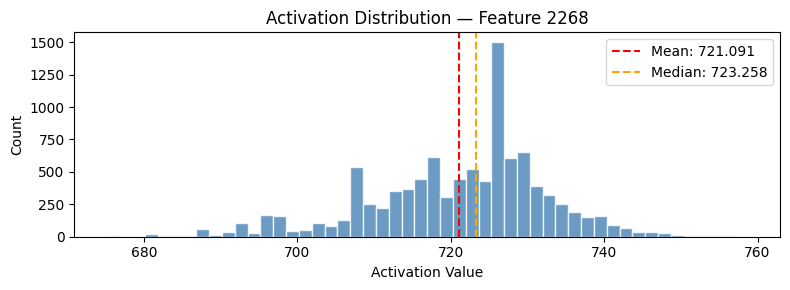


--- Co-occurring Features ---


,feature_id,co_occurrence_count,token_ids
0,1091,904,"[9360, 14134, 18947, 324, 24441, 4507, 16991, ..."
1,1195,904,"[29449, 48035, 9360, 40202, 14134, 18947, 1435..."
2,2194,904,"[3844, 37338, 14662, 27429, 14350, 2202, 24915..."
3,315,904,"[3844, 37338, 14662, 27429, 14350, 2202, 24915..."
4,146,904,"[25391, 4342, 13152, 18153, 11002, 12976, 1368..."
...,...,...,...
1053,2778,1,[3856]
1054,605,1,[18273]
1055,1977,1,[18819]
1056,1793,1,[6090]



--- Token Type Breakdown ---
  pos: {'PROPN': 304, 'NOUN': 254, 'X': 121, 'VERB': 85, 'ADJ': 60, 'ADV': 37, 'NUM': 34, 'PUNCT': 24, 'ADP': 23, 'PRON': 17, 'AUX': 13, 'DET': 11, 'SPACE': 8, 'SCONJ': 4, 'CCONJ': 3, 'PART': 1, 'INTJ': 1}
  ner: {'O': 794, 'ORG': 97, 'PERSON': 60, 'NORP': 9, 'CARDINAL': 8, 'DATE': 7, 'PRODUCT': 7, 'WORK_OF_ART': 5, 'GPE': 5, 'LAW': 2, 'LOC': 2, 'EVENT': 2, 'QUANTITY': 1, 'TIME': 1}
  is_stop: {False: 943, True: 57}
  is_punct: {False: 990, True: 10}
  dep: {'compound': 233, '': 112, 'ROOT': 80, 'nsubj': 71, 'punct': 56, 'amod': 54, 'dobj': 52, 'appos': 47, 'nmod': 42, 'pobj': 35, 'advmod': 34, 'prep': 27, 'nummod': 26, 'npadvmod': 17, 'dep': 17, 'attr': 15, 'ccomp': 14, 'conj': 11, 'det': 11, 'aux': 8, 'poss': 6, 'acl': 4, 'nsubjpass': 3, 'dative': 3, 'advcl': 3, 'relcl': 3, 'xcomp': 3, 'preconj': 2, 'cc': 2, 'parataxis': 2, 'acomp': 2, 'oprd': 1, 'intj': 1, 'mark': 1, 'meta': 1, 'pcomp': 1}
  subword_position: {'word_medial': 1000}
  is_numeric: {False: 

In [7]:
inspect_idx = 0  # 0 to len(batch_results)-1

r = batch_results[inspect_idx]
print(f"[{inspect_idx + 1}/{len(batch_results)}]")
display_feature_result(r, show_histogram=True)

# Aggregate Analysis

### Monosemanticity Rate

In [8]:
polysemantic_count = sum(
    1 for r in batch_results if "POLYSEMANTIC" in r["llm_label"].upper()
)
total_count = len(batch_results)
monosemantic_rate = 1 - (polysemantic_count / total_count)

print(f"Monosemanticity Rate: {monosemantic_rate:.1%}")
print(f"  Polysemantic: {polysemantic_count}/{total_count}")
print(f"  Monosemantic: {total_count - polysemantic_count}/{total_count}")

for group in ["top-k", "bottom-k"]:
    group_results = [r for r in batch_results if r["group"] == group]
    group_poly = sum(1 for r in group_results if "POLYSEMANTIC" in r["llm_label"].upper())
    print(f"  {group}: {len(group_results) - group_poly}/{len(group_results)} monosemantic "
          f"({1 - group_poly / len(group_results):.1%})")

Monosemanticity Rate: 80.0%
  Polysemantic: 10/50
  Monosemantic: 40/50
  top-k: 23/25 monosemantic (92.0%)
  bottom-k: 17/25 monosemantic (68.0%)


### Feature Density

,feature_id,group,llm_label,mean_activation,median_activation,std_activation,unique_tokens,feature_density
0,2268,top-k,POLYSEMANTIC,721.090637,723.258118,11.553864,1873,5.757709e-05
1,2194,top-k,THE at article/sentence start,668.147278,669.421387,12.275955,1873,5.757709e-05
2,593,top-k,Standalone numeral “1” marker,481.525238,479.573212,14.309177,1873,5.758284e-05
3,801,top-k,News article lead-in words/names,413.559113,413.484589,4.654372,1873,5.757709e-05
4,315,top-k,WASHINGTON dateline headlines,378.314636,378.133331,5.036415,1873,5.757709e-05
5,1581,top-k,News outlet/source headers,330.272400,330.657440,3.864817,1873,5.757709e-05
6,1944,top-k,Preposition “barring” meaning except for,8.733263,8.706945,0.949012,1,5.757709e-08
7,935,top-k,Interstate highway references,9.245881,8.846053,1.427238,1,6.909250e-08
8,19,top-k,POLYSEMANTIC,8.202880,8.144669,1.221807,13,7.485021e-08
9,1667,top-k,Phrase “of all”,8.231130,7.953517,0.886171,1,8.636563e-08


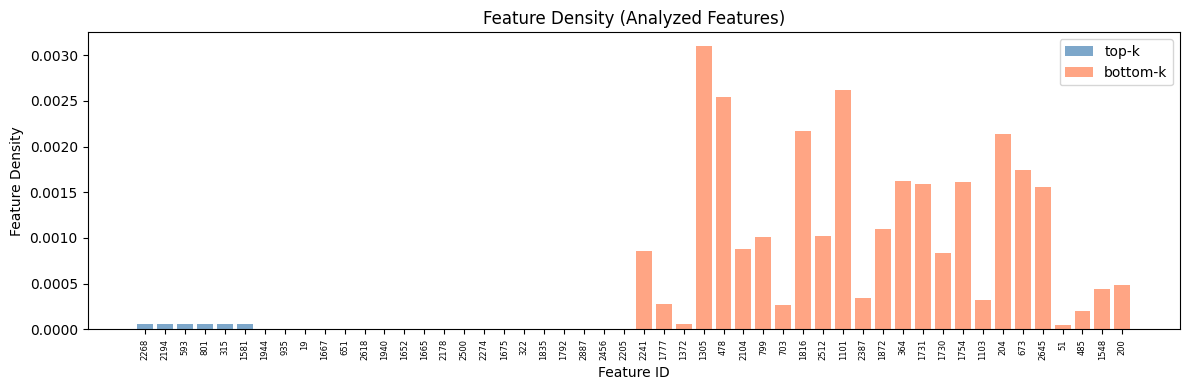

In [9]:
density_df = feature_analyzer.get_feature_density(table_name)

batch_summary_with_density = batch_summary_df.merge(density_df, on="feature_id", how="left")
display(batch_summary_with_density)

fig, ax = plt.subplots(figsize=(12, 4))
for group, color in [("top-k", "steelblue"), ("bottom-k", "coral")]:
    group_data = batch_summary_with_density[batch_summary_with_density["group"] == group]
    ax.bar(
        group_data["feature_id"].astype(str),
        group_data["feature_density"],
        color=color, alpha=0.7, label=group
    )
ax.set_xlabel("Feature ID")
ax.set_ylabel("Feature Density")
ax.set_title("Feature Density (Analyzed Features)")
ax.legend()
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

### Pairwise Feature Similarity

Computing similarity matrix:   0%|          | 0/50 [00:00<?, ?it/s]

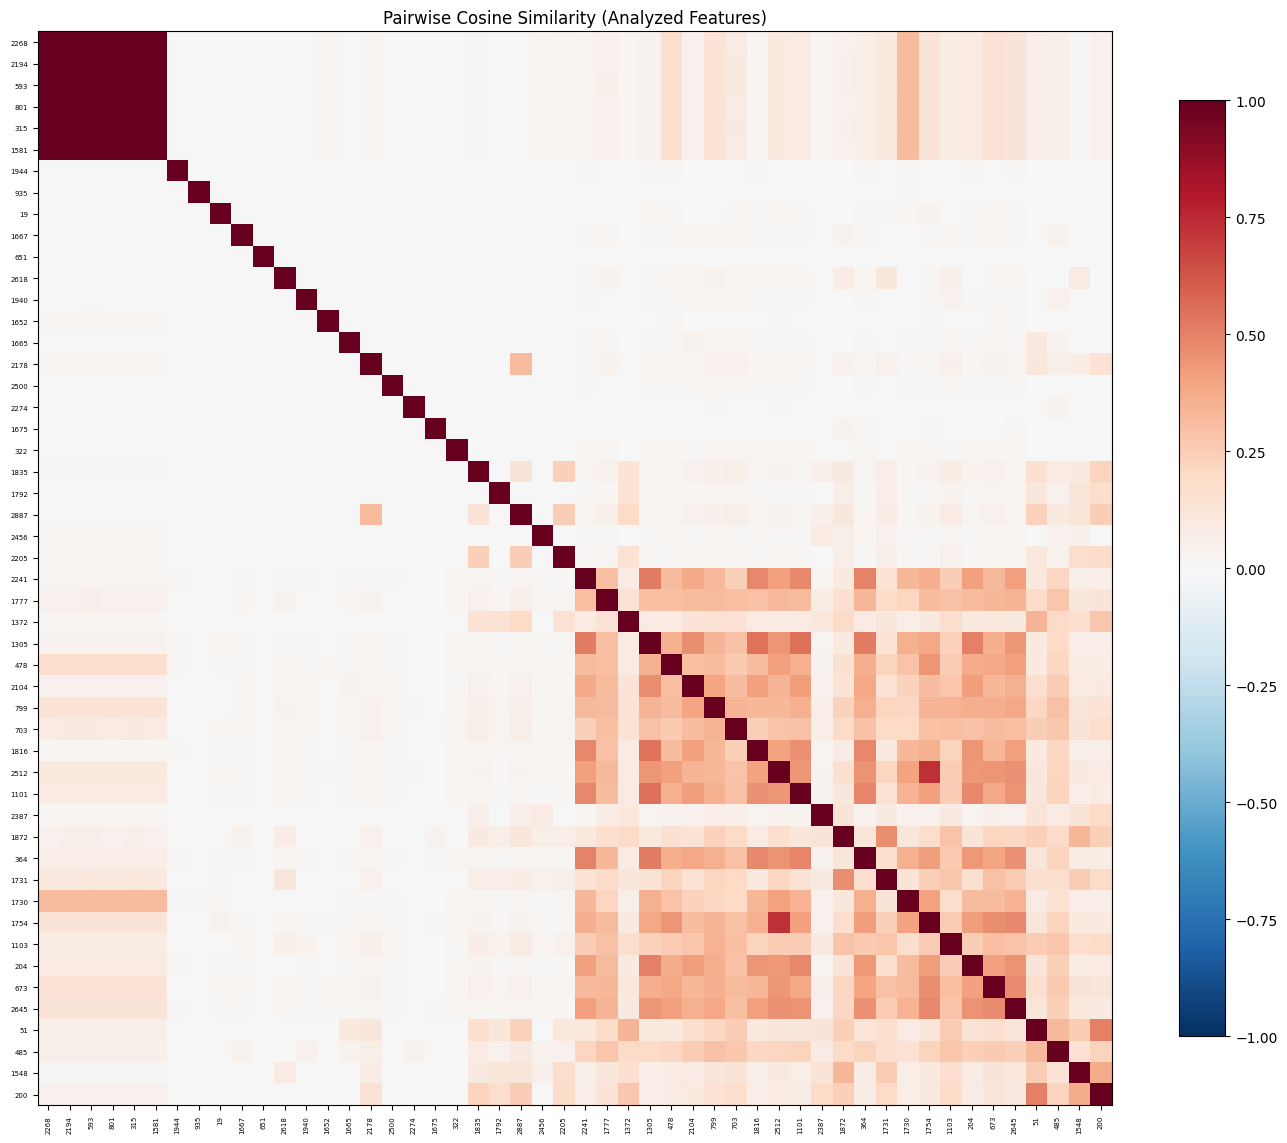

In [10]:
analyzed_feature_ids = [r["feature_id"] for r in batch_results]
n = len(analyzed_feature_ids)

sim_matrix = np.eye(n)
for i in tqdm(range(n), desc="Computing similarity matrix"):
    for j in range(i + 1, n):
        sim = feature_analyzer.feature_similarity_cosine_similarity(
            table_name, int(analyzed_feature_ids[i]), int(analyzed_feature_ids[j])
        )
        sim_matrix[i, j] = sim
        sim_matrix[j, i] = sim

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sim_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
labels = [str(fid) for fid in analyzed_feature_ids]
ax.set_xticklabels(labels, rotation=90, fontsize=5)
ax.set_yticklabels(labels, fontsize=5)
ax.set_title("Pairwise Cosine Similarity (Analyzed Features)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### Activation Distribution Grid

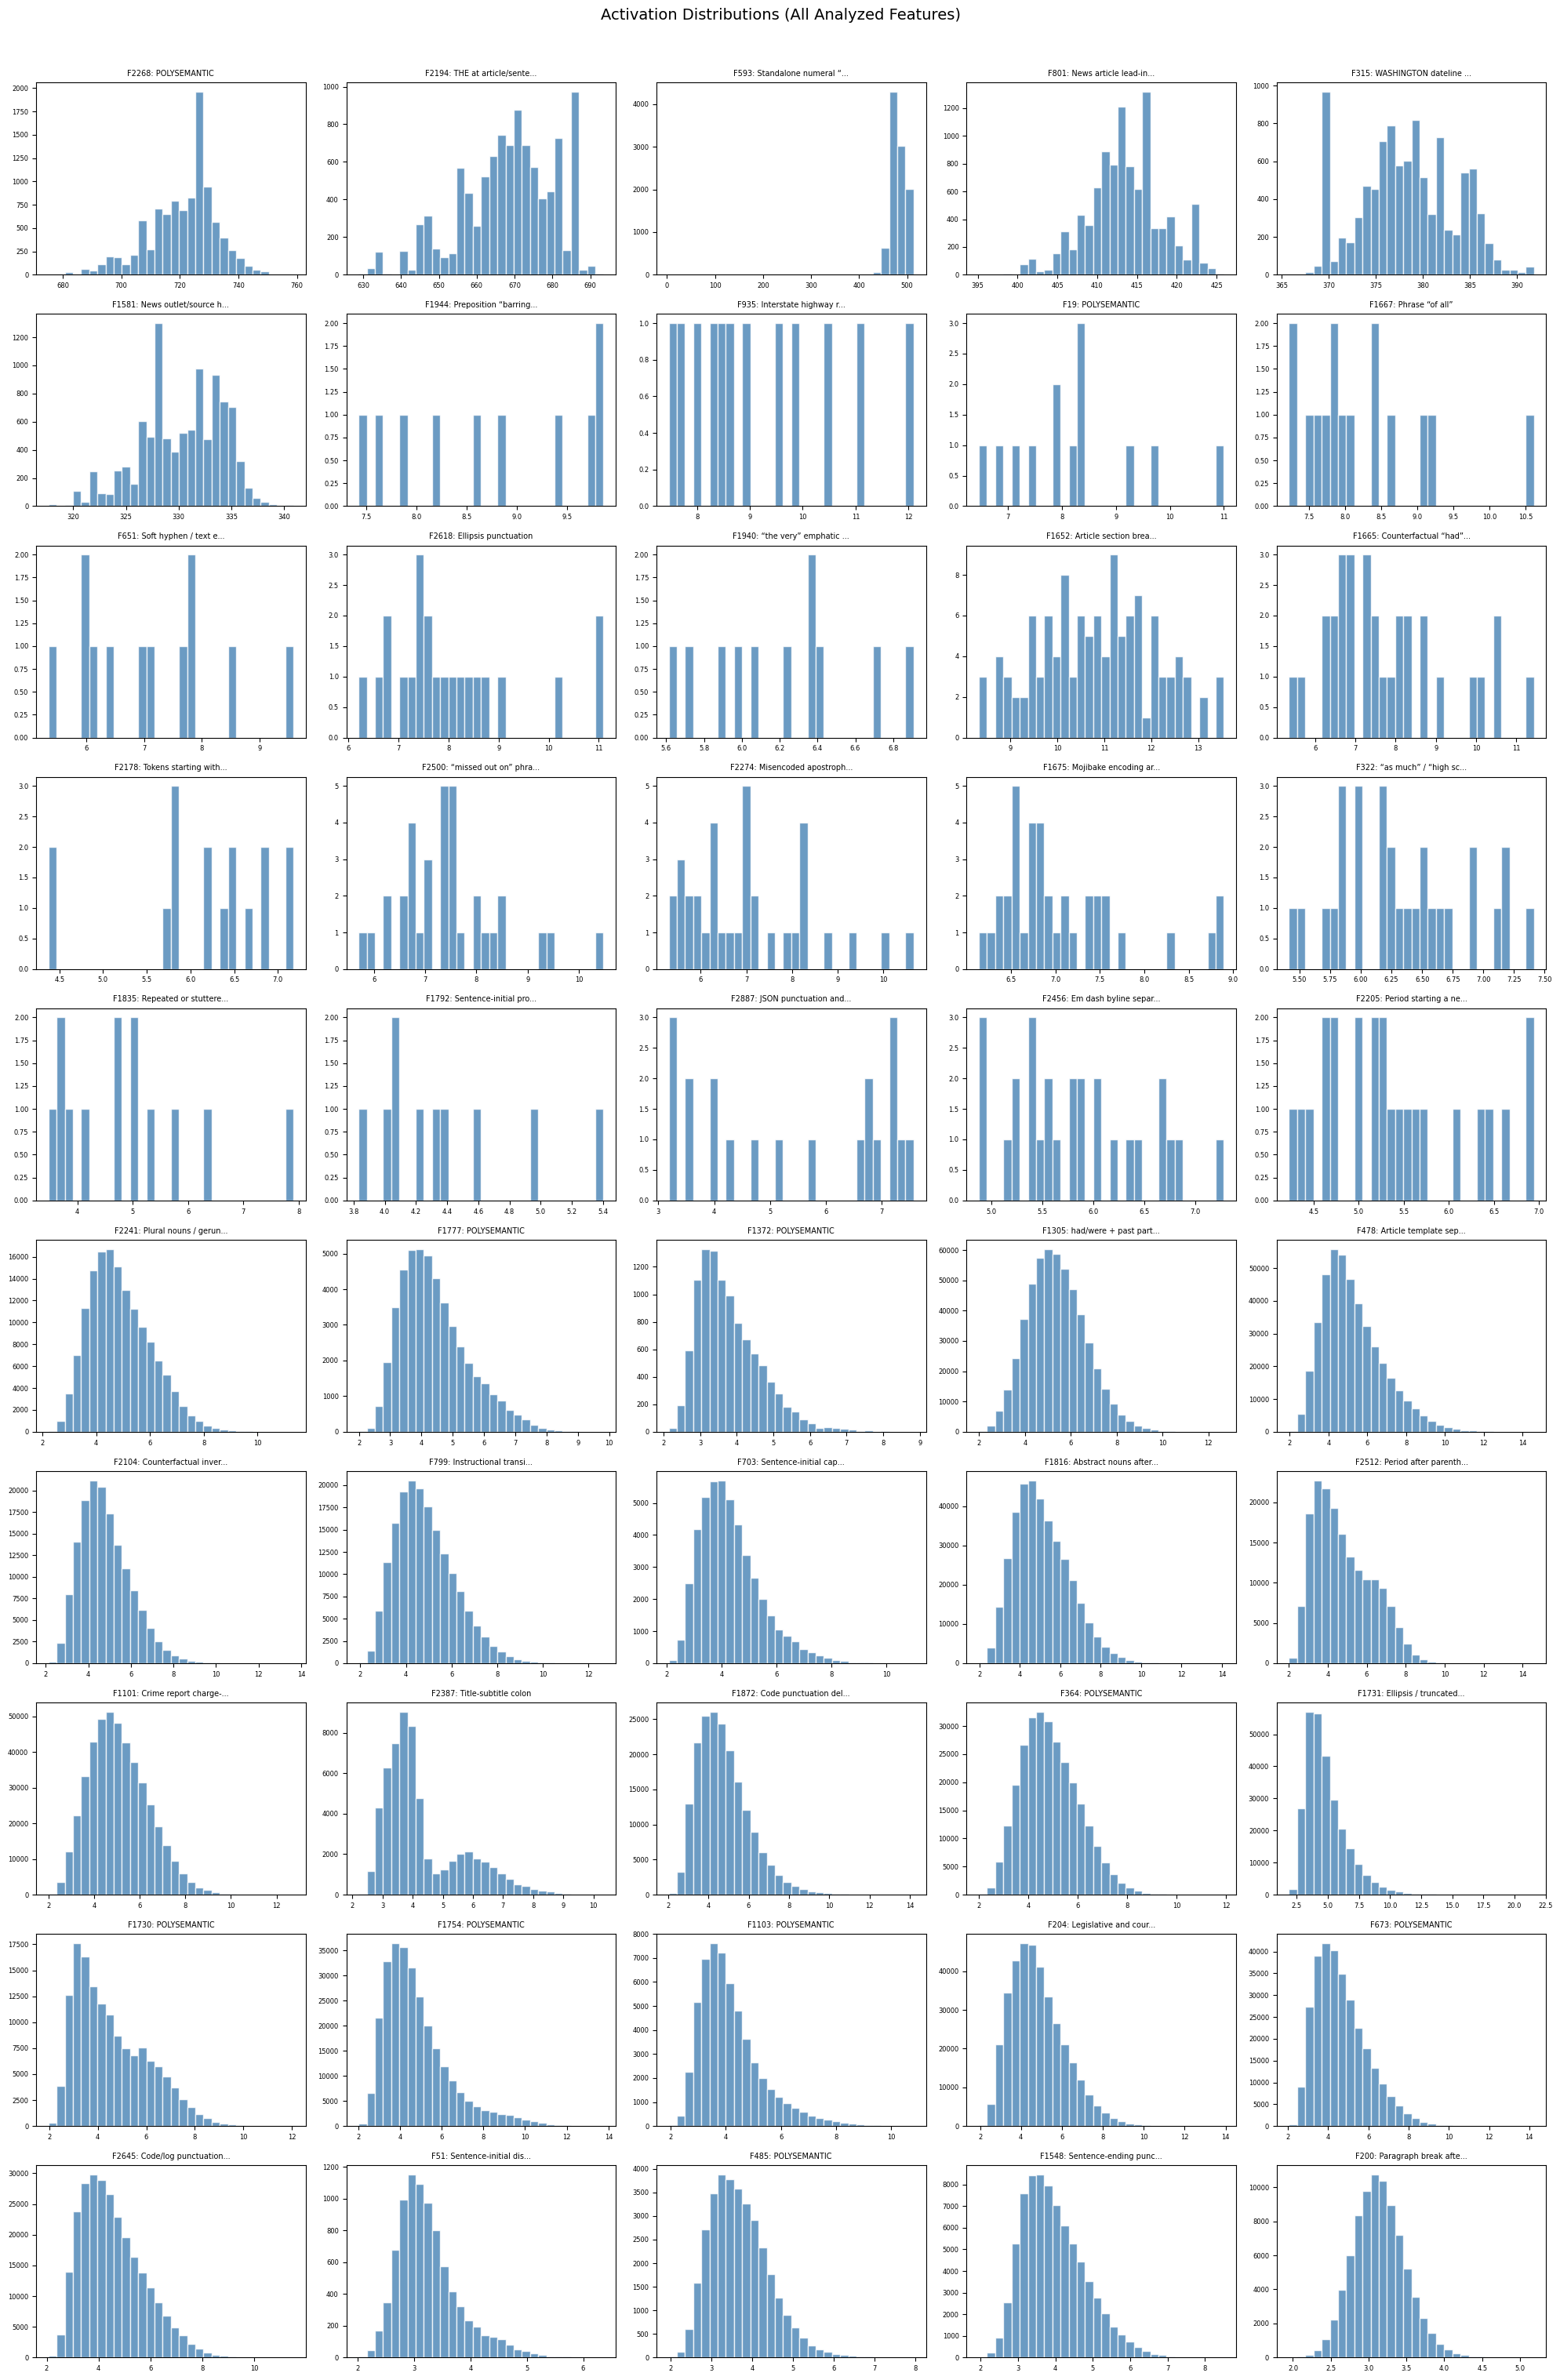

In [11]:
n_cols = 5
n_rows = (len(batch_results) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for idx, r in enumerate(batch_results):
    ax = axes[idx]
    ax.hist(r["raw_activations"], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    label_short = r["llm_label"][:20] + "..." if len(r["llm_label"]) > 20 else r["llm_label"]
    ax.set_title(f"F{r['feature_id']}: {label_short}", fontsize=7)
    ax.tick_params(labelsize=6)

for idx in range(len(batch_results), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Activation Distributions (All Analyzed Features)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Dead Feature Proportions

In [12]:
dead_df = feature_analyzer.get_dead_features()
dead_df

,feature_id
0,3
1,4
2,6
3,18
4,23
...,...
469,3051
470,3053
471,3055
472,3063


In [13]:
dead_proportion = len(dead_df)/(expansion_factor*gpt_dim)
dead_proportion

0.154296875